In [1]:
# ============================================================
# 0011 — ADDITIONAL EXPERIMENTS
# ============================================================

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount("/content/drive")

PROJECT_ROOT = Path("/content/drive/MyDrive/FitnessML_Master")

TABLES_DIR = PROJECT_ROOT / "tables"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "results" / "0011_additional_experiments"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("0011 — ADDITIONAL EXPERIMENTS")
print("=" * 70)
print(f"Project root: {PROJECT_ROOT}")
print(f"Output dir:   {OUTPUT_DIR}")

Mounted at /content/drive
0011 — ADDITIONAL EXPERIMENTS
Project root: /content/drive/MyDrive/FitnessML_Master
Output dir:   /content/drive/MyDrive/FitnessML_Master/results/0011_additional_experiments


In [3]:
# ============================================================
# LOAD MODELING DATASET
# ============================================================

MODEL_PATH = PROCESSED_DIR / "fitbit_modeling_features.csv"
DAILY_PATH = PROCESSED_DIR / "fitbit_daily_processed.csv"

modeling = pd.read_csv(MODEL_PATH)
modeling["ActivityDate"] = pd.to_datetime(modeling["ActivityDate"])

TARGET = "target_calories_next_day"

# Canonical 13 base features
BASE_FEATURES = [
    "TotalSteps",
    "TotalDistance",
    "TrackerDistance",
    "LoggedActivitiesDistance",
    "VeryActiveDistance",
    "ModeratelyActiveDistance",
    "LightActiveDistance",
    "SedentaryActiveDistance",
    "VeryActiveMinutes",
    "FairlyActiveMinutes",
    "LightlyActiveMinutes",
    "SedentaryMinutes",
    "Calories",
]

# ------------------------------------------------------------
# Restore base features if current modeling CSV is legacy
# ------------------------------------------------------------

missing_base = [
    feature
    for feature in BASE_FEATURES
    if feature not in modeling.columns
]

if missing_base:
    print(
        f"Legacy modeling dataset detected. "
        f"Restoring {len(missing_base)} base features."
    )

    daily = pd.read_csv(DAILY_PATH)
    daily["ActivityDate"] = pd.to_datetime(daily["ActivityDate"])

    modeling = modeling.merge(
        daily[
            ["Id", "ActivityDate"] + missing_base
        ],
        on=["Id", "ActivityDate"],
        how="left",
        validate="one_to_one",
    )

# ------------------------------------------------------------
# Detect temporal features
# ------------------------------------------------------------

lag_features = [
    column
    for column in modeling.columns
    if "_lag_" in column
]

rolling_features = [
    column
    for column in modeling.columns
    if "rolling_" in column
]

feature_columns = (
    BASE_FEATURES
    + lag_features
    + rolling_features
)

# Remove accidental duplicates while preserving order
feature_columns = list(dict.fromkeys(feature_columns))

# ------------------------------------------------------------
# Final modeling dataset
# ------------------------------------------------------------

modeling = (
    modeling
    .dropna(subset=feature_columns + [TARGET])
    .sort_values(["ActivityDate", "Id"])
    .reset_index(drop=True)
)

print("=" * 70)
print("MODELING DATASET")
print("=" * 70)

print(f"Rows:             {len(modeling)}")
print(f"Base features:    {len(BASE_FEATURES)}")
print(f"Lag features:     {len(lag_features)}")
print(f"Rolling features: {len(rolling_features)}")
print(f"Total features:   {len(feature_columns)}")

assert len(modeling) == 680, (
    f"Expected 680 observations, got {len(modeling)}."
)

assert len(feature_columns) == 65, (
    f"Expected 65 features, got {len(feature_columns)}."
)

print("\n✓ Canonical modeling dataset is valid.")

MODELING DATASET
Rows:             680
Base features:    13
Lag features:     28
Rolling features: 24
Total features:   65

✓ Canonical modeling dataset is valid.


In [4]:
# ============================================================
# WALK-FORWARD FOLDS
# ============================================================

FOLDS = [
    {
        "fold": 1,
        "train_end": 256,
        "test_end": 410,
    },
    {
        "fold": 2,
        "train_end": 410,
        "test_end": 555,
    },
    {
        "fold": 3,
        "train_end": 555,
        "test_end": 680,
    },
]

fold_structure = pd.DataFrame(
    [
        {
            "fold": fold["fold"],
            "train_size": fold["train_end"],
            "test_size": fold["test_end"] - fold["train_end"],
        }
        for fold in FOLDS
    ]
)

print("=" * 70)
print("WALK-FORWARD FOLDS")
print("=" * 70)

display(fold_structure)

# ------------------------------------------------------------
# Previous 006 results for reference
# ------------------------------------------------------------

reference_path = TABLES_DIR / "006_validation_summary.csv"

if reference_path.exists():
    print("\n006 reference results:")

    validation_reference = pd.read_csv(reference_path)
    display(validation_reference.round(4))
else:
    print("\n006 reference table not found.")

WALK-FORWARD FOLDS


,fold,train_size,test_size
0,1,256,154
1,2,410,145
2,3,555,125



006 reference results:


,model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,Random Forest — All Features,373.7911,94.3970,563.8099,154.0266,0.4381,0.1637
1,7-Day Mean,366.4455,98.6326,566.3899,166.4228,0.4325,0.1890
2,User Mean,367.9359,102.9410,572.8226,156.4973,0.4199,0.1693
3,Linear Regression — Base,389.7171,92.3465,576.5766,141.1027,0.4124,0.1377
4,Decision Tree — Base,404.6027,81.0518,582.5245,121.5451,0.3992,0.1001


In [5]:
# ============================================================
# MODEL FACTORIES
# ============================================================

RF_PARAMS = {
    "n_estimators": 200,
    "max_depth": 10,
    "min_samples_leaf": 3,
    "random_state": 42,
    "n_jobs": -1,
}


def make_rf():
    return RandomForestRegressor(**RF_PARAMS)


# ------------------------------------------------------------
# Boosting model
# ------------------------------------------------------------

try:
    from xgboost import XGBRegressor

    BOOSTING_NAME = "XGBoost"

    def make_boosting():
        return XGBRegressor(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=3,
            reg_lambda=1.0,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1,
        )

except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor

    BOOSTING_NAME = "Gradient Boosting"

    def make_boosting():
        return GradientBoostingRegressor(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.05,
            min_samples_leaf=3,
            random_state=42,
        )


print("=" * 70)
print("MODELS")
print("=" * 70)

print("Random Forest")
print(f"Boosting model: {BOOSTING_NAME}")

MODELS
Random Forest
Boosting model: XGBoost


In [6]:
# ============================================================
# PERSONALIZED TARGET
# ============================================================

def fit_personal_baseline(train_ids, train_y):
    baseline_data = pd.DataFrame(
        {
            "Id": train_ids.to_numpy(),
            "target": train_y.to_numpy(),
        }
    )

    user_baseline = (
        baseline_data
        .groupby("Id")["target"]
        .mean()
    )

    global_baseline = float(train_y.mean())

    return user_baseline, global_baseline


def to_deviation(
    ids,
    y,
    user_baseline,
    global_baseline,
):
    baseline = (
        ids
        .map(user_baseline)
        .fillna(global_baseline)
        .to_numpy(dtype=float)
    )

    return (
        y.to_numpy(dtype=float)
        - baseline
    )


def to_absolute(
    ids,
    predicted_deviation,
    user_baseline,
    global_baseline,
):
    baseline = (
        ids
        .map(user_baseline)
        .fillna(global_baseline)
        .to_numpy(dtype=float)
    )

    return (
        np.asarray(predicted_deviation, dtype=float)
        + baseline
    )


print("✓ Personalization functions ready.")

✓ Personalization functions ready.


In [7]:
# ============================================================
# WALK-FORWARD EVALUATION
# ============================================================

def evaluate(
    factory,
    label,
    features=None,
    personalized=False,
):
    if features is None:
        features = feature_columns

    rows = []

    for fold in FOLDS:
        train = modeling.iloc[
            :fold["train_end"]
        ].copy()

        test = modeling.iloc[
            fold["train_end"]:fold["test_end"]
        ].copy()

        X_train = train[features]
        X_test = test[features]

        y_train = train[TARGET].astype(float)
        y_test = test[TARGET].astype(float)

        model = factory()

        # ----------------------------------------------------
        # Personalized target
        # ----------------------------------------------------

        if personalized:
            user_baseline, global_baseline = (
                fit_personal_baseline(
                    train["Id"],
                    y_train,
                )
            )

            y_train_deviation = to_deviation(
                train["Id"],
                y_train,
                user_baseline,
                global_baseline,
            )

            model.fit(
                X_train,
                y_train_deviation,
            )

            predicted_deviation = model.predict(X_test)

            predictions = to_absolute(
                test["Id"],
                predicted_deviation,
                user_baseline,
                global_baseline,
            )

        # ----------------------------------------------------
        # Absolute target
        # ----------------------------------------------------

        else:
            model.fit(
                X_train,
                y_train,
            )

            predictions = model.predict(X_test)

        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        mae = mean_absolute_error(
            y_test,
            predictions,
        )

        rmse = mean_squared_error(
            y_test,
            predictions,
        ) ** 0.5

        r2 = r2_score(
            y_test,
            predictions,
        )

        rows.append(
            {
                "fold": fold["fold"],
                "model": label,
                "MAE": mae,
                "RMSE": rmse,
                "R2": r2,
                "train_size": len(train),
                "test_size": len(test),
            }
        )

    fold_results = pd.DataFrame(rows)

    summary = pd.DataFrame(
        [
            {
                "model": label,

                "MAE_mean": fold_results["MAE"].mean(),
                "MAE_std": fold_results["MAE"].std(ddof=1),

                "RMSE_mean": fold_results["RMSE"].mean(),
                "RMSE_std": fold_results["RMSE"].std(ddof=1),

                "R2_mean": fold_results["R2"].mean(),
                "R2_std": fold_results["R2"].std(ddof=1),
            }
        ]
    )

    return fold_results, summary


print("✓ Walk-forward evaluator ready.")

✓ Walk-forward evaluator ready.


In [8]:
# ============================================================
# MODEL × PERSONALIZATION EXPERIMENT
# ============================================================

experiments = [
    (
        "Random Forest — Absolute",
        make_rf,
        False,
    ),
    (
        f"{BOOSTING_NAME} — Absolute",
        make_boosting,
        False,
    ),
    (
        "Random Forest — Personalized Target",
        make_rf,
        True,
    ),
    (
        f"{BOOSTING_NAME} — Personalized Target",
        make_boosting,
        True,
    ),
]

fold_parts = []
summary_parts = []

print("=" * 70)
print("MODEL × PERSONALIZATION")
print("=" * 70)

for label, factory, personalized in experiments:
    print(f"\nRunning: {label}")

    fold_result, summary_result = evaluate(
        factory=factory,
        label=label,
        personalized=personalized,
    )

    fold_parts.append(fold_result)
    summary_parts.append(summary_result)


additional_fold_results = pd.concat(
    fold_parts,
    ignore_index=True,
)

additional_summary = pd.concat(
    summary_parts,
    ignore_index=True,
)

additional_summary = (
    additional_summary
    .sort_values("R2_mean", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)

display(
    additional_summary.round(4)
)

MODEL × PERSONALIZATION

Running: Random Forest — Absolute

Running: XGBoost — Absolute

Running: Random Forest — Personalized Target

Running: XGBoost — Personalized Target

SUMMARY


,model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,Random Forest — Absolute,373.7911,94.3970,563.8099,154.0266,0.4381,0.1637
1,Random Forest — Personalized Target,372.0603,91.2659,573.0168,144.4052,0.4195,0.1452
2,XGBoost — Personalized Target,384.0544,80.1739,582.8054,133.3013,0.3993,0.1222
3,XGBoost — Absolute,395.7691,87.4358,585.0638,147.3745,0.3950,0.1506


In [9]:
# ============================================================
# WALK-FORWARD CALORIES-HISTORY ABLATION
# ============================================================

calories_history_features = [
    feature
    for feature in feature_columns
    if (
        feature == "Calories"
        or feature.startswith("Calories_lag_")
        or feature.startswith("Calories_rolling_")
    )
]

no_calories_features = [
    feature
    for feature in feature_columns
    if feature not in calories_history_features
]

print("=" * 70)
print("CALORIES-HISTORY ABLATION")
print("=" * 70)

print(f"Full features:            {len(feature_columns)}")
print(f"Calories-history group:   {len(calories_history_features)}")
print(f"Without Calories history: {len(no_calories_features)}")

ablation_experiments = [
    (
        "Random Forest — All Features",
        feature_columns,
    ),
    (
        "Random Forest — Without Calories History",
        no_calories_features,
    ),
]

ablation_parts = []

for label, features in ablation_experiments:
    print(f"\nRunning: {label}")

    fold_result, _ = evaluate(
        factory=make_rf,
        label=label,
        features=features,
        personalized=False,
    )

    ablation_parts.append(fold_result)


ablation_walk_forward = pd.concat(
    ablation_parts,
    ignore_index=True,
)

ablation_summary = (
    ablation_walk_forward
    .groupby("model")
    .agg(
        MAE_mean=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std"),
        R2_mean=("R2", "mean"),
        R2_std=("R2", "std"),
    )
    .reset_index()
)

display(
    ablation_summary.round(4)
)

CALORIES-HISTORY ABLATION
Full features:            65
Calories-history group:   9
Without Calories history: 56

Running: Random Forest — All Features

Running: Random Forest — Without Calories History


,model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,Random Forest — All Features,373.7911,94.3970,563.8099,154.0266,0.4381,0.1637
1,Random Forest — Without Calories History,490.4907,69.7454,655.9055,96.8298,0.2339,0.0471


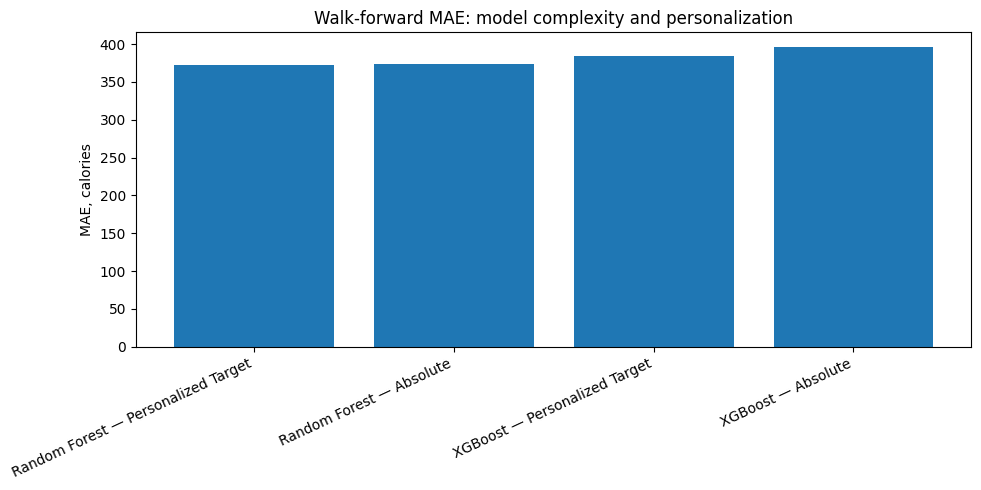

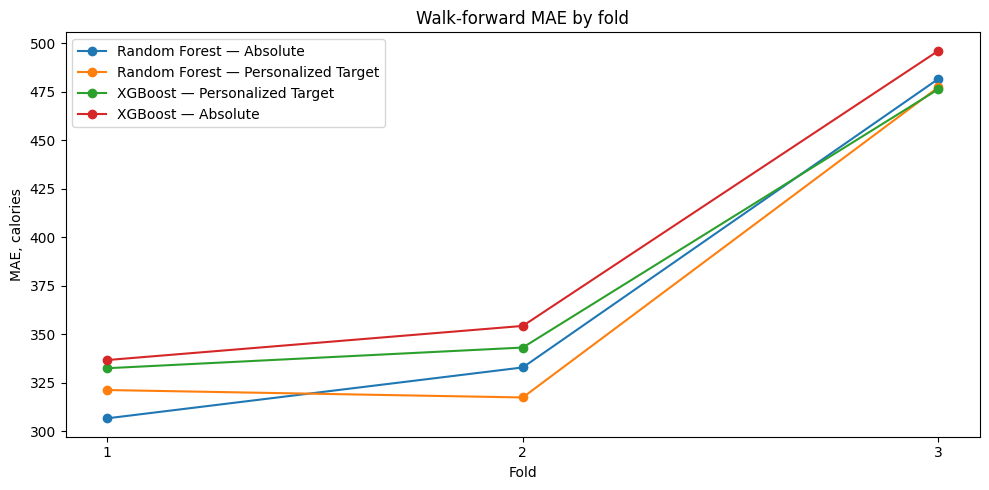

In [10]:
# ============================================================
# VISUALIZATION
# ============================================================

plot_data = (
    additional_summary
    .sort_values("MAE_mean")
)

plt.figure(figsize=(10, 5))

plt.bar(
    plot_data["model"],
    plot_data["MAE_mean"],
)

plt.ylabel("MAE, calories")
plt.title(
    "Walk-forward MAE: "
    "model complexity and personalization"
)

plt.xticks(
    rotation=25,
    ha="right",
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# MAE by fold
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

for model_name in additional_summary["model"]:
    model_results = additional_fold_results[
        additional_fold_results["model"] == model_name
    ]

    plt.plot(
        model_results["fold"],
        model_results["MAE"],
        marker="o",
        label=model_name,
    )

plt.xlabel("Fold")
plt.ylabel("MAE, calories")
plt.title("Walk-forward MAE by fold")

plt.xticks([1, 2, 3])
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# FINAL COMPARISON AND EXPORT
# ============================================================

rf_reference = additional_summary.loc[
    additional_summary["model"]
    == "Random Forest — Absolute"
].iloc[0]

comparison = additional_summary.copy()

comparison["MAE_change_vs_RF"] = (
    comparison["MAE_mean"]
    - rf_reference["MAE_mean"]
)

comparison["R2_change_vs_RF"] = (
    comparison["R2_mean"]
    - rf_reference["R2_mean"]
)


# ------------------------------------------------------------
# Calories-history ablation delta
# ------------------------------------------------------------

rf_full = ablation_summary.loc[
    ablation_summary["model"]
    == "Random Forest — All Features"
].iloc[0]

rf_no_history = ablation_summary.loc[
    ablation_summary["model"]
    == "Random Forest — Without Calories History"
].iloc[0]


print("=" * 70)
print("KEY DELTAS VS RANDOM FOREST — ABSOLUTE")
print("=" * 70)

for _, row in comparison.iterrows():

    if row["model"] == "Random Forest — Absolute":
        continue

    print(
        f"{row['model']}: "
        f"ΔMAE={row['MAE_change_vs_RF']:+.2f}, "
        f"ΔR²={row['R2_change_vs_RF']:+.4f}"
    )


print("\n" + "=" * 70)
print("CALORIES-HISTORY ABLATION")
print("=" * 70)

print(
    "ΔMAE="
    f"{rf_no_history['MAE_mean'] - rf_full['MAE_mean']:+.2f}"
)

print(
    "ΔR²="
    f"{rf_no_history['R2_mean'] - rf_full['R2_mean']:+.4f}"
)


# ============================================================
# EXPORT
# ============================================================

additional_fold_results.to_csv(
    OUTPUT_DIR / "0011_additional_walk_forward_results.csv",
    index=False,
)

additional_summary.to_csv(
    OUTPUT_DIR / "0011_additional_model_summary.csv",
    index=False,
)

ablation_walk_forward.to_csv(
    OUTPUT_DIR / "0011_calories_history_ablation_walk_forward.csv",
    index=False,
)

ablation_summary.to_csv(
    OUTPUT_DIR / "0011_calories_history_ablation_summary.csv",
    index=False,
)

comparison.to_csv(
    OUTPUT_DIR / "0011_main_comparison.csv",
    index=False,
)


metadata = {
    "notebook": "0011",
    "features": len(feature_columns),
    "observations": len(modeling),

    "folds": [
        {
            "fold": fold["fold"],
            "train": fold["train_end"],
            "test": (
                fold["test_end"]
                - fold["train_end"]
            ),
        }
        for fold in FOLDS
    ],

    "boosting_model": BOOSTING_NAME,

    "personalization": (
        "target deviation from "
        "user training baseline"
    ),

    "calories_history_group_size": (
        len(calories_history_features)
    ),

    "features_without_calories_history": (
        len(no_calories_features)
    ),
}

with open(
    OUTPUT_DIR / "0011_metadata.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metadata,
        file,
        ensure_ascii=False,
        indent=2,
    )


print("\n" + "=" * 70)
print("EXPORT COMPLETE")
print("=" * 70)

print(f"Directory: {OUTPUT_DIR}")

KEY DELTAS VS RANDOM FOREST — ABSOLUTE
Random Forest — Personalized Target: ΔMAE=-1.73, ΔR²=-0.0186
XGBoost — Personalized Target: ΔMAE=+10.26, ΔR²=-0.0388
XGBoost — Absolute: ΔMAE=+21.98, ΔR²=-0.0431

CALORIES-HISTORY ABLATION
ΔMAE=+116.70
ΔR²=-0.2041

EXPORT COMPLETE
Directory: /content/drive/MyDrive/FitnessML_Master/results/0011_additional_experiments
